<a href="https://colab.research.google.com/github/miansemab/Console_Base_Calculator/blob/master/Customer_Support_Intent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning
  Machine learning is a subset of artificial intelligence that uses data and algorithms to let computers learn and make predictions without being explicitly programmed.

#### Types of ML
1. Supervise Learning(Labeled Data)
2. Unsupervise Learning(Unlabeled Data)
3. Reiforcement Learning(Trail n Errors)

#### Flow
Dataset -> EDA(Explortry Data Analysis) -> Data Split -> Model Selection -> Model Train -> Evalution -> HyperParameter Tunning -> Deploy

In [1]:
!pip -q install datasets

In [2]:
from datasets import load_dataset

dataset = load_dataset(
    "bitext/Bitext-customer-support-llm-chatbot-training-dataset"
)

df = dataset["train"].to_pandas()

print("Rows, columns:", df.shape)
display(df.head(3))

README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

Bitext_Sample_Customer_Support_Training_(…): reconstructing file:   0%|          |  0.00B / 19.2MB            

Bitext_Sample_Customer_Support_Training_(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

Rows, columns: (26872, 5)


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...


In [3]:
df = df[["instruction", "intent"]].copy()

df = df.dropna()
df = df.drop_duplicates(subset=["instruction", "intent"])

print("Clean rows:", len(df))
print("Number of intents:", df["intent"].nunique())
display(df["intent"].value_counts())

Clean rows: 24635
Number of intents: 27


,count
intent,
contact_customer_service,1000
complaint,1000
check_payment_methods,999
contact_human_agent,999
newsletter_subscription,999
payment_issue,999
delivery_period,999
registration_problems,999
place_order,998


In [4]:
df.sample(5, random_state=42)

,instruction,intent
21634,I have an issue with the online registration,registration_problems
10327,can you help me to open a standard account?,create_account
25636,"I want to locate order {{Order Number}}, could...",track_order
13628,how could I check how long it takes for my par...,delivery_period
2594,i need help chanigng the shipping address,change_shipping_address


Total intents: 27


,messages
intent,
contact_customer_service,1000
complaint,1000
check_payment_methods,999
contact_human_agent,999
newsletter_subscription,999
payment_issue,999
delivery_period,999
registration_problems,999
place_order,998


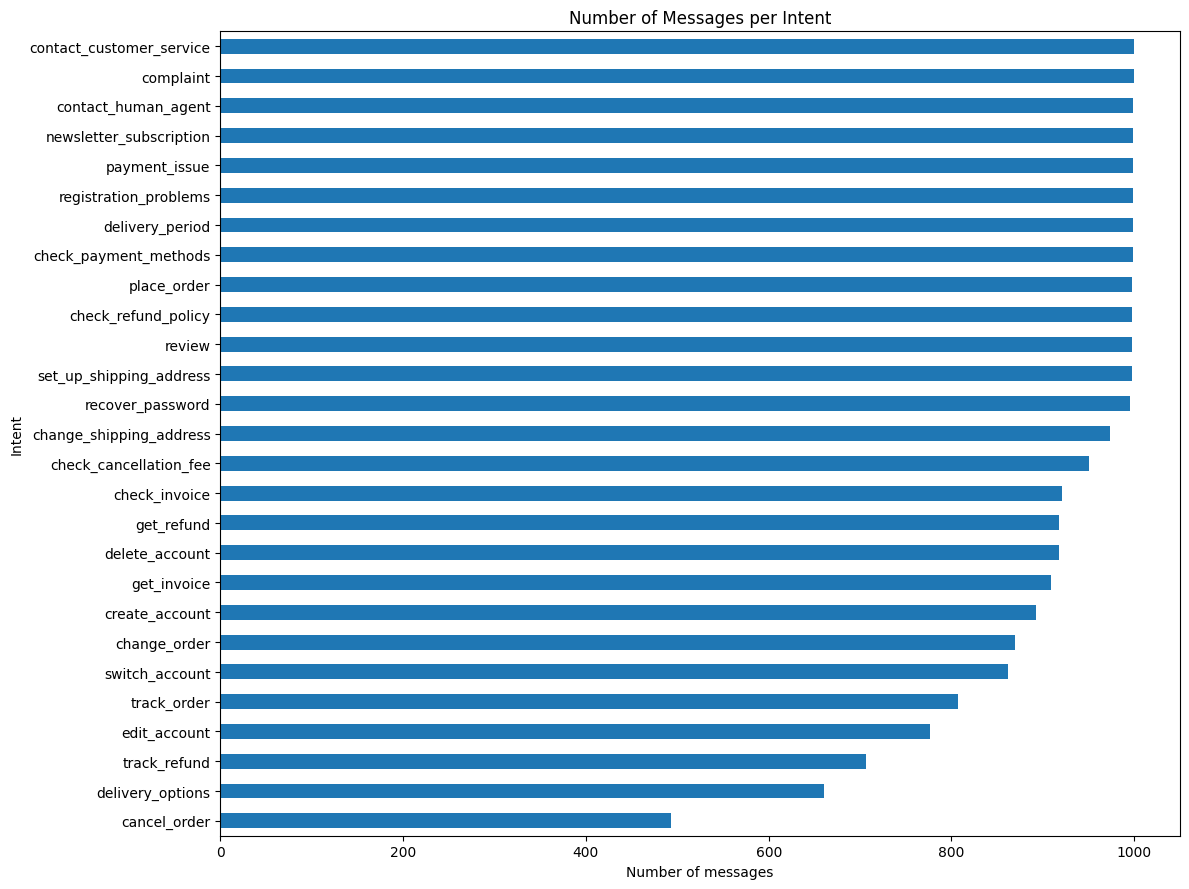

In [5]:
import matplotlib.pyplot as plt

intent_counts = df["intent"].value_counts()

print("Total intents:", len(intent_counts))
display(intent_counts.to_frame(name="messages"))

plt.figure(figsize=(12, 9))
intent_counts.sort_values().plot(kind="barh")
plt.title("Number of Messages per Intent")
plt.xlabel("Number of messages")
plt.ylabel("Intent")
plt.tight_layout()
plt.show()

,word_count
count,24635.000000
mean,8.861904
std,2.567765
min,1.000000
25%,7.000000
50%,9.000000
75%,11.000000
max,16.000000


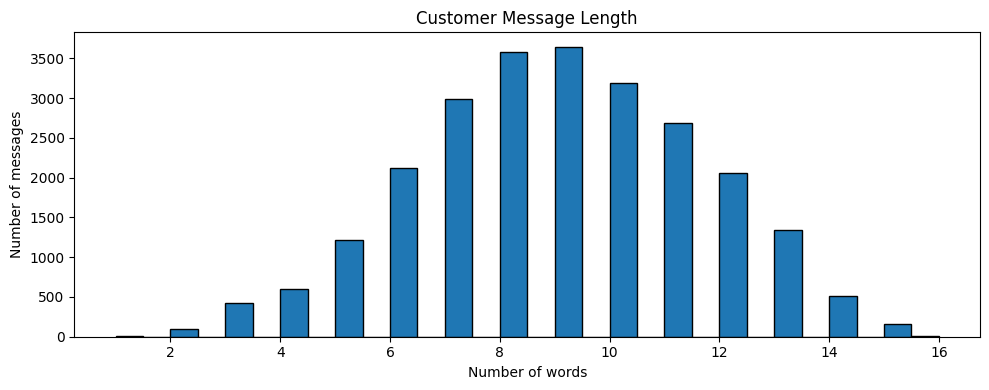


Shortest messages:


,instruction,intent,word_count
7449,complaint,complaint,1
9025,contactingassistant,contact_human_agent,1
10231,register,create_account,1
19665,makepurchase,place_order,1
22443,review,review,1



Longest messages:


,instruction,intent,word_count
9942,I do not know what to do to create a {{Account...,create_account,16
9951,I want to open a {{Account Type}} account for ...,create_account,16
10969,I do not know what I have to do to remove a da...,delete_account,16
13603,i have to see how soon can i expect my item oh...,delivery_period,16
16526,i have paid {{Currency Symbol}}{{Refund Amount...,get_refund,16


In [6]:
df["word_count"] = df["instruction"].str.split().str.len()

display(df["word_count"].describe())

plt.figure(figsize=(10, 4))
plt.hist(df["word_count"], bins=30, edgecolor="black")
plt.title("Customer Message Length")
plt.xlabel("Number of words")
plt.ylabel("Number of messages")
plt.tight_layout()
plt.show()

print("\nShortest messages:")
display(df.nsmallest(5, "word_count")[["instruction", "intent", "word_count"]])

print("\nLongest messages:")
display(df.nlargest(5, "word_count")[["instruction", "intent", "word_count"]])

In [7]:
for intent in ["cancel_order", "track_order", "get_refund", "contact_human_agent"]:
    print(f"\n--- {intent} ---")
    examples = df.loc[df["intent"] == intent, "instruction"].head(3)
    for message in examples:
        print("-", message)


--- cancel_order ---
- question about cancelling order {{Order Number}}
- i have a question about cancelling oorder {{Order Number}}
- i need help cancelling puchase {{Order Number}}

--- track_order ---
- needx help to check the ETA of purchase {{Order Number}}
- ETA of purchase {{Order Number}}
- need to check the eta of order {{Order Number}}

--- get_refund ---
- how do I get a compensation of my money?
- i do not know what i have to do to get my money back
- I want assistace to request a compensation of my money

--- contact_human_agent ---
- I do not understand you, help me chatting with someone
- can I talk to a person?
- I can't speak with a live agent


In [8]:
from sklearn.model_selection import train_test_split

X = df["instruction"]
y = df["intent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training messages:", len(X_train))
print("Test messages:", len(X_test))
print("Training intents:", y_train.nunique())
print("Test intents:", y_test.nunique())

Training messages: 19708
Test messages: 4927
Training intents: 27
Test intents: 27


In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

model_1 = make_pipeline(
    CountVectorizer(),
    MultinomialNB()
)

model_1.fit(X_train, y_train)
print("Naive Bayes model trained")

Naive Bayes model trained


In [14]:
y_pred_1 = model_1.predict(X_test)

print("Message:", X_test.iloc[0])
print("Actual intent:", y_test.iloc[0])
print("Predicted intent:", y_pred_1[0])
X_test.iloc[0]

Message: I have tl talk to a live agent
Actual intent: contact_human_agent
Predicted intent: contact_human_agent


'I have tl talk to a live agent'

In [11]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_1 = accuracy_score(y_test, y_pred_1)

print(f"Model 1 Accuracy: {accuracy_1:.2%}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_1, zero_division=0))

Model 1 Accuracy: 98.74%

Classification report:
                          precision    recall  f1-score   support

            cancel_order       0.99      0.95      0.97        99
            change_order       0.92      0.98      0.95       174
 change_shipping_address       0.97      0.99      0.98       195
  check_cancellation_fee       0.99      1.00      1.00       190
           check_invoice       0.99      0.99      0.99       184
   check_payment_methods       1.00      1.00      1.00       200
     check_refund_policy       0.98      0.99      0.98       199
               complaint       1.00      1.00      1.00       200
contact_customer_service       1.00      0.99      0.99       200
     contact_human_agent       0.99      0.99      0.99       200
          create_account       0.98      0.97      0.98       178
          delete_account       0.98      0.99      0.99       184
        delivery_options       1.00      1.00      1.00       132
         delivery_period  

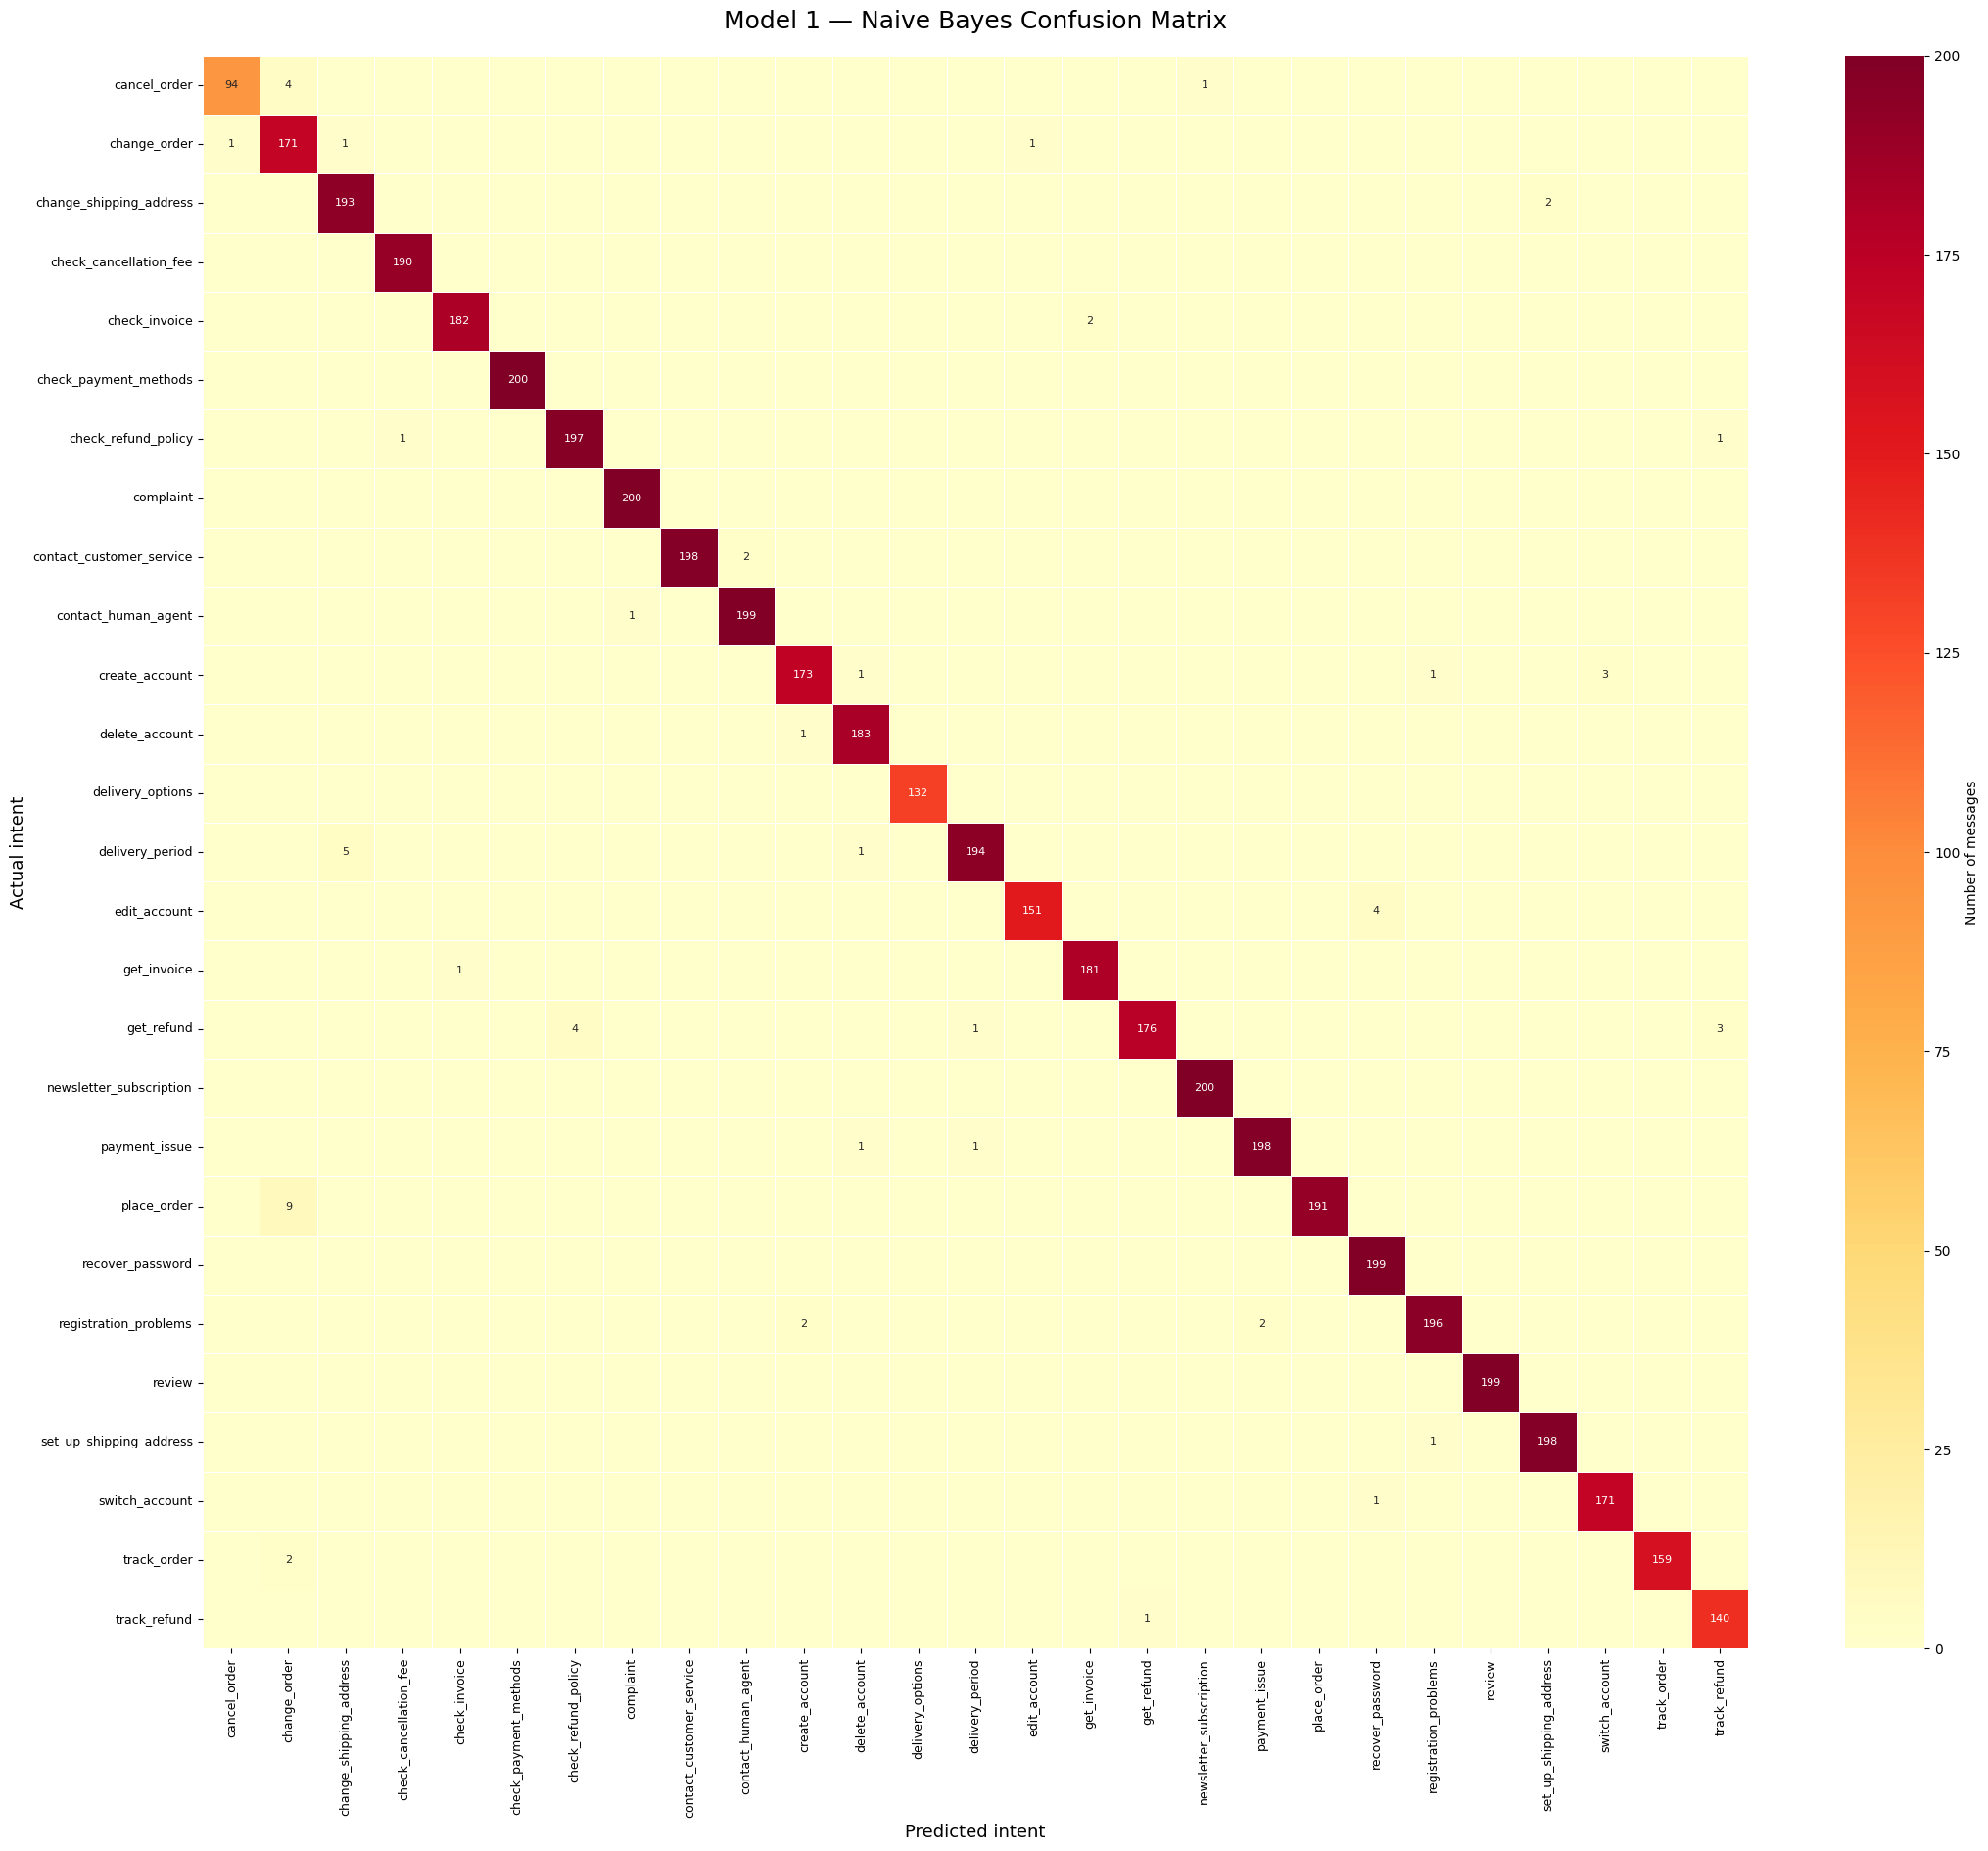

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

labels = sorted(y_train.unique())
cm_1 = confusion_matrix(y_test, y_pred_1, labels=labels)

annotations_1 = np.where(cm_1 == 0, "", cm_1.astype(str))

plt.figure(figsize=(22, 19))

sns.heatmap(
    cm_1,
    annot=annotations_1,
    fmt="",
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="white",
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 8},
    cbar_kws={"label": "Number of messages"}
)

plt.title("Model 1 — Naive Bayes Confusion Matrix", fontsize=18, pad=20)
plt.xlabel("Predicted intent", fontsize=13)
plt.ylabel("Actual intent", fontsize=13)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

In [15]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

model_2 = make_pipeline(
    TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2
    ),
    LinearSVC(random_state=42)
)

model_2.fit(X_train, y_train)
print("Model 2 trained successfully")

Model 2 trained successfully


In [16]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

y_pred_2 = model_2.predict(X_test)

accuracy_2 = accuracy_score(y_test, y_pred_2)
macro_f1_2 = f1_score(y_test, y_pred_2, average="macro")

print(f"Model 1 (Naive Bayes) accuracy: {accuracy_1:.2%}")
print(f"Model 2 (TF-IDF + SVM) accuracy: {accuracy_2:.2%}")
print(f"Model 2 macro F1: {macro_f1_2:.3f}")

print("\nModel 2 classification report:")
print(classification_report(y_test, y_pred_2, zero_division=0))

Model 1 (Naive Bayes) accuracy: 98.74%
Model 2 (TF-IDF + SVM) accuracy: 99.25%
Model 2 macro F1: 0.992

Model 2 classification report:
                          precision    recall  f1-score   support

            cancel_order       0.96      0.96      0.96        99
            change_order       0.97      0.97      0.97       174
 change_shipping_address       1.00      1.00      1.00       195
  check_cancellation_fee       0.99      1.00      0.99       190
           check_invoice       0.96      1.00      0.98       184
   check_payment_methods       1.00      1.00      1.00       200
     check_refund_policy       1.00      0.99      1.00       199
               complaint       1.00      1.00      1.00       200
contact_customer_service       1.00      0.98      0.99       200
     contact_human_agent       0.99      0.99      0.99       200
          create_account       0.99      0.97      0.98       178
          delete_account       0.97      1.00      0.99       184
      

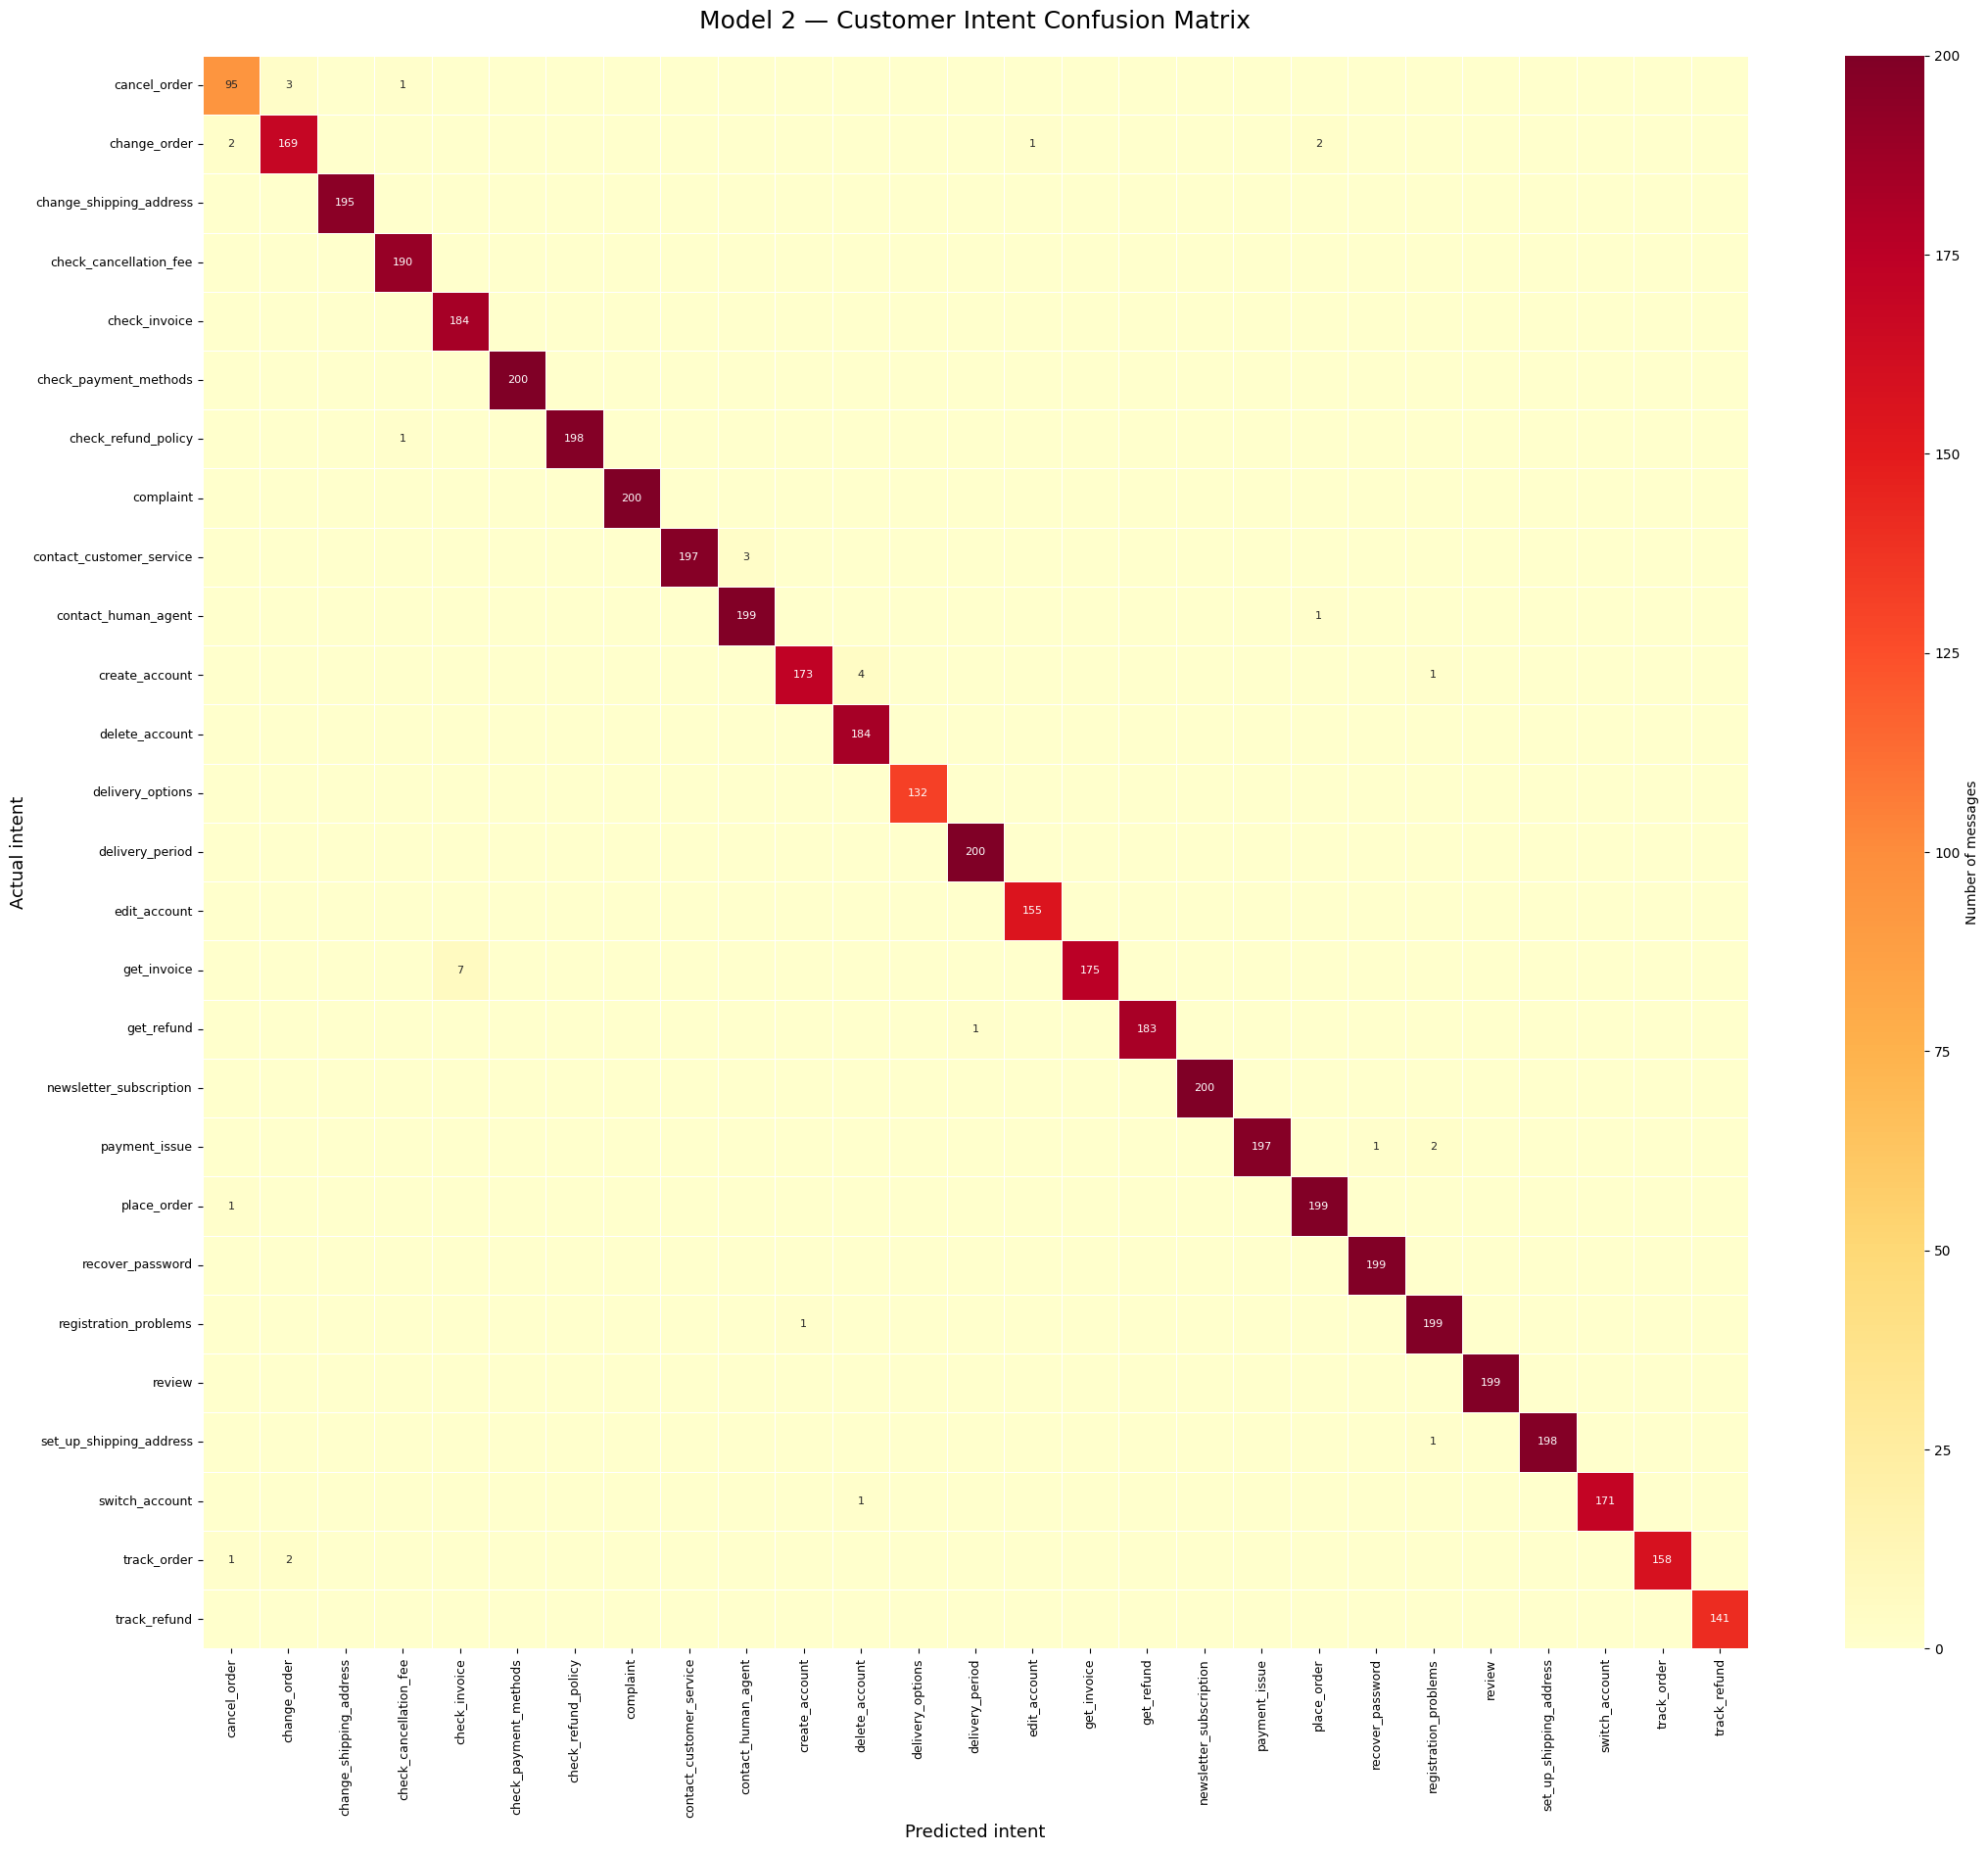

In [17]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

labels = sorted(y_train.unique())
cm = confusion_matrix(y_test, y_pred_2, labels=labels)

annotations = np.where(cm == 0, "", cm.astype(str))

plt.figure(figsize=(22, 19))

sns.heatmap(
    cm,
    annot=annotations,
    fmt="",
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="white",
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 8},
    cbar_kws={"label": "Number of messages"}
)

plt.title("Model 2 — Customer Intent Confusion Matrix", fontsize=18, pad=20)
plt.xlabel("Predicted intent", fontsize=13)
plt.ylabel("Actual intent", fontsize=13)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "tfidfvectorizer__ngram_range": [(1, 1), (1, 2)],
    "tfidfvectorizer__min_df": [2, 5],
    "linearsvc__C": [0.5, 2.0],
}

grid_search = GridSearchCV(
    estimator=model_2,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=2,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validation macro F1: {grid_search.best_score_:.3f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'linearsvc__C': 2.0, 'tfidfvectorizer__min_df': 2, 'tfidfvectorizer__ngram_range': (1, 1)}
Best cross-validation macro F1: 0.993


In [19]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

model_2_tuned = grid_search.best_estimator_
y_pred_2_tuned = model_2_tuned.predict(X_test)

print(f"Before tuning accuracy: {accuracy_2:.2%}")
print(f"After tuning accuracy:  {accuracy_score(y_test, y_pred_2_tuned):.2%}")

print(f"Before tuning macro F1: {macro_f1_2:.3f}")
print(f"After tuning macro F1:  {f1_score(y_test, y_pred_2_tuned, average='macro'):.3f}")

print("\nTuned model classification report:")
print(classification_report(y_test, y_pred_2_tuned, zero_division=0))

Before tuning accuracy: 99.25%
After tuning accuracy:  99.37%
Before tuning macro F1: 0.992
After tuning macro F1:  0.993

Tuned model classification report:
                          precision    recall  f1-score   support

            cancel_order       0.96      0.96      0.96        99
            change_order       0.98      0.99      0.98       174
 change_shipping_address       1.00      0.99      1.00       195
  check_cancellation_fee       0.99      1.00      0.99       190
           check_invoice       0.97      1.00      0.99       184
   check_payment_methods       1.00      1.00      1.00       200
     check_refund_policy       1.00      0.99      1.00       199
               complaint       1.00      1.00      1.00       200
contact_customer_service       0.99      0.99      0.99       200
     contact_human_agent       0.99      1.00      1.00       200
          create_account       0.99      0.98      0.99       178
          delete_account       0.98      0.99    

In [20]:
!pip -q install gradio

In [21]:
import gradio as gr

def predict_intent(message):
    if not message or not message.strip():
        return "Please enter a customer message."

    intent = model_2_tuned.predict([message.strip()])[0]
    return intent.replace("_", " ").title()

demo = gr.Interface(
    fn=predict_intent,
    inputs=gr.Textbox(
        label="Customer message",
        placeholder="Example: Where is my order?",
        lines=3
    ),
    outputs=gr.Textbox(label="Predicted intent"),
    title="Customer Support Intent Classifier",
    description="Enter a customer message to identify what the customer wants.",
    examples=[
        ["Where is my order?"],
        ["I want to cancel my purchase."],
        ["I forgot my password."],
    ]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6d9188d9555f1cc72f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
